In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv(
    'data.txt',
    sep=';',
    skiprows=1,
    names=['start_date_time', 'RCORR_E'],
    parse_dates=['start_date_time']
)

print("Размер данных:", df.shape)
print("Количество NULL в RCORR_E:", df['RCORR_E'].isna().sum())
print(df.head())

Размер данных: (12901, 2)
Количество NULL в RCORR_E: 0
      start_date_time  RCORR_E
0 2015-08-01 00:00:00   97.600
1 2015-08-01 00:01:00   96.267
2 2015-08-01 00:02:00   98.667
3 2015-08-01 00:03:00   96.933
4 2015-08-01 00:04:00   95.333


In [36]:
full_range = pd.date_range(
    start=df['start_date_time'].min(),
    end=df['start_date_time'].max(),
    freq='1min'
)

existing = set(df['start_date_time'])

missing_minutes = [t for t in full_range if t not in existing]

print(f"Всего минут в диапазоне: {len(full_range)}")
print(f"Пропущено минут: {len(missing_minutes)}")
print(f"Доля пропущенных минут: {len(missing_minutes)/len(full_range):.3f}")

if missing_minutes:
    df_missing = pd.DataFrame({
        'start_date_time': missing_minutes,
        'RCORR_E': np.nan
    })
    df = pd.concat([df, df_missing], ignore_index=True)
    df = df.sort_values('start_date_time').reset_index(drop=True)

Всего минут в диапазоне: 12960
Пропущено минут: 59
Доля пропущенных минут: 0.005


In [38]:
df_sigma = df.copy()

missing_mask = df_sigma['RCORR_E'].isna()

valid_data = df_sigma.loc[~missing_mask, 'RCORR_E']
mean_val = valid_data.mean()
std_val = valid_data.std()

outlier_mask = (df_sigma['RCORR_E'] < mean_val - 3 * std_val) | \
               (df_sigma['RCORR_E'] > mean_val + 3 * std_val)
outlier_mask = outlier_mask & (~missing_mask)

print(f"Среднее: {mean_val:.3f}, стандартное отклонение: {std_val:.3f}")
print(f"Количество выбросов по правилу 3 сигма: {outlier_mask.sum()}")
print(f"Доля выбросов: {outlier_mask.sum()/len(full_range):.3f}")

clean_data_sigma = df_sigma.loc[~missing_mask & ~outlier_mask, 'RCORR_E']
median_sigma = clean_data_sigma.median()
print(f"Медиана: {median_sigma:.3f}")

df_sigma.loc[missing_mask | outlier_mask, 'RCORR_E'] = median_sigma

Среднее: 109.730, стандартное отклонение: 79.651
Количество выбросов по правилу 3 сигма: 198
Доля выбросов: 0.015
Медиана: 97.867


In [39]:
df_iqr = df.copy()

missing_mask_iqr = df_iqr['RCORR_E'].isna()

valid_data_iqr = df_iqr.loc[~missing_mask_iqr, 'RCORR_E']
Q1 = valid_data_iqr.quantile(0.25)
Q3 = valid_data_iqr.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask_iqr = (df_iqr['RCORR_E'] < lower_bound) | (df_iqr['RCORR_E'] > upper_bound)
outlier_mask_iqr = outlier_mask_iqr & (~missing_mask_iqr)

print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
print(f"Границы: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Количество выбросов по правилу IQR: {outlier_mask_iqr.sum()}")
print(f"Доля выбросов: {outlier_mask_iqr.sum()/len(full_range):.3f}")

clean_data_iqr = df_iqr.loc[~missing_mask_iqr & ~outlier_mask_iqr, 'RCORR_E']
median_iqr = clean_data_iqr.median()
print(f"Медиана: {median_iqr:.3f}")

df_iqr.loc[missing_mask_iqr | outlier_mask_iqr, 'RCORR_E'] = median_iqr

Q1 = 96.400, Q3 = 99.600, IQR = 3.200
Границы: [91.600, 104.400]
Количество выбросов по правилу IQR: 2102
Доля выбросов: 0.162
Медиана: 97.733


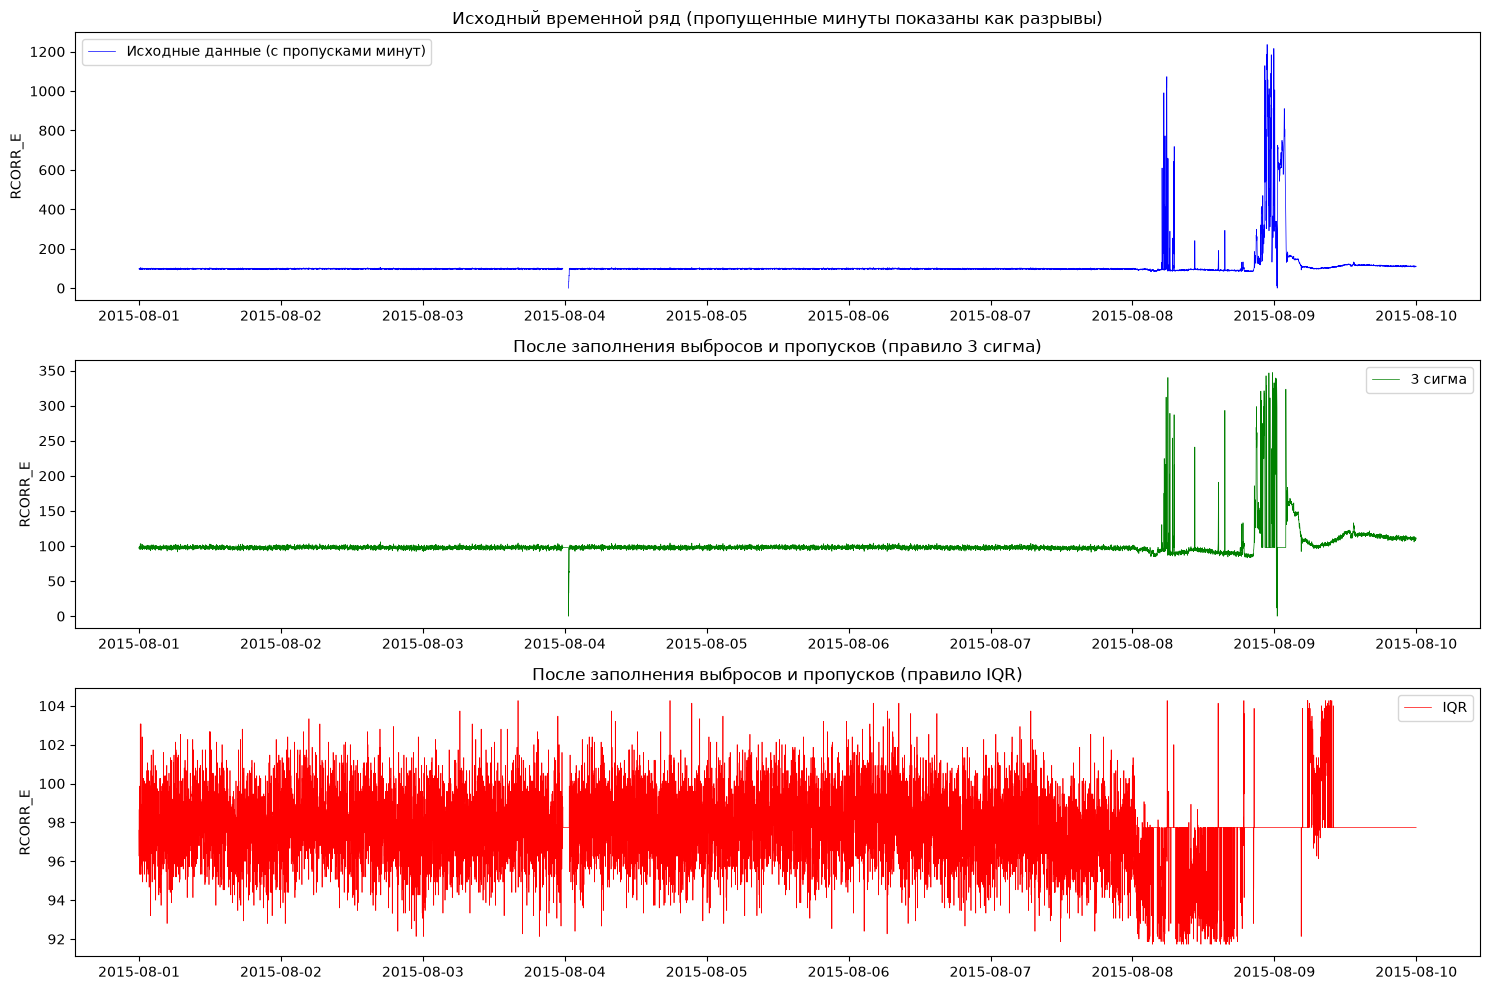

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(df['start_date_time'], df['RCORR_E'],
             color='blue', linewidth=0.5,
             label='Исходные данные (с пропусками минут)')
axes[0].set_title('Исходный временной ряд (пропущенные минуты показаны как разрывы)')
axes[0].set_ylabel('RCORR_E')
axes[0].legend()

axes[1].plot(df_sigma['start_date_time'], df_sigma['RCORR_E'],
             color='green', linewidth=0.5, label='3 сигма')
axes[1].set_title('После заполнения выбросов и пропусков (правило 3 сигма)')
axes[1].set_ylabel('RCORR_E')
axes[1].legend()

axes[2].plot(df_iqr['start_date_time'], df_iqr['RCORR_E'],
             color='red', linewidth=0.5, label='IQR')
axes[2].set_title('После заполнения выбросов и пропусков (правило IQR)')
axes[2].set_ylabel('RCORR_E')
axes[2].legend()

fig.tight_layout()

# fig.savefig('timeseries_plots.png', dpi=150, bbox_inches='tight')

plt.show()